In [24]:

import os 
import sys
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

sys.path.append("../")
PATH = "../../"

# No feature selection - all 15 variables

In [25]:
''' 
Prepare data --> change here for different setups!
'''

### Manually selected vars
varFolder = "manual_selection"
var = f"allVars_mgfaRecoded"  

''' 
Read data
'''
metrics = ["precision",
            "recall",
            "f1",
            "accuracy",
            "model",
            "auc",
            "average_prec"]

PATH_res = f"{PATH}/results/30_predictions/{varFolder}/{var}/modelComparison"
df = pd.read_csv(f"{PATH_res}/prediction_cv_test_rfc.csv")
df.index = metrics
df = df.T
df.drop(["model"], axis=1, inplace=True)
df = df.astype("float64")

## Table + calculate CI

In [26]:
# confidence intervals
alpha = 0.95

In [27]:
dic_CI = dict()
for i in df.columns:
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(df[i], p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(df[i], p))

    dic_CI[i] = [lower*100, df[i].mean()*100, upper*100]

df_CI = pd.DataFrame.from_dict(dic_CI)
df_CI.index = ["lower CI", "mean", "upper CI"]
#df_CI.to_csv(f"{PATH_res}/CI_performances.csv")

df_CI

,precision,recall,f1,accuracy,auc,average_prec
lower CI,69.957709,68.230222,70.556546,67.915231,74.107301,76.961172
mean,73.092622,74.154341,73.533711,70.137836,76.493026,79.881038
upper CI,76.242922,80.485494,76.161300,72.003790,79.065731,82.735844


(0.5, 1.0)

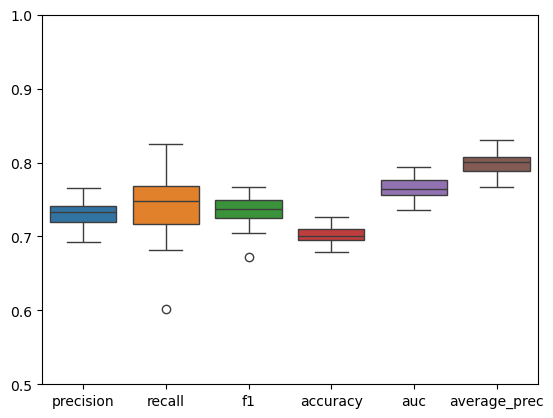

In [28]:
fig, ax = plt.subplots()

df_15 = df.copy()
df_15["vars"] = "manual"
sns.boxplot(data=df_15)
ax.set_ylim(0.5, 1)

# Feature selection - 5 variables 

In [29]:
''' 
Prepare data --> change here for different setups!
'''

### Feature selected vars
target="gender"
percentBoruta = 100
varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"

''' 
Read data
'''
metrics = ["precision",
                            "recall",
                            "f1",
                            "accuracy",
                            "model",
                            "auc",
                            "average_prec"]

PATH_res = f"{PATH}/results/30_predictions/{varFolder}/{var}/modelComparison"
df = pd.read_csv(f"{PATH_res}/prediction_cv_test_rfc.csv")
df.index = metrics
df = df.T
df.drop(["model"], axis=1, inplace=True)
df = df.astype("float64")

## Table

In [30]:
# confidence intervals
alpha = 0.95

In [31]:
dic_CI = dict()
for i in df.columns:
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(df[i], p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(df[i], p))

    dic_CI[i] = [lower*100, df[i].mean()*100, upper*100]

df_CI = pd.DataFrame.from_dict(dic_CI)
df_CI.index = ["lower CI", "mean", "upper CI"]
df_CI.to_csv(f"{PATH_res}/CI_performances.csv")

df_CI

,precision,recall,f1,accuracy,auc,average_prec
lower CI,62.184332,66.552017,66.518393,60.666782,65.118450,70.379243
mean,68.373620,74.098613,70.995959,66.045963,71.270589,75.265804
upper CI,73.202916,82.020489,73.590057,69.588215,75.053761,79.149334


(0.5, 1.0)

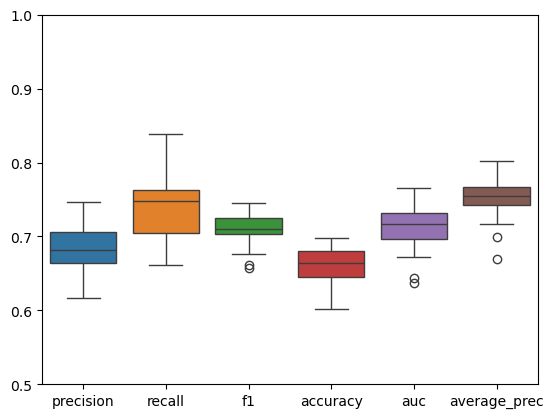

In [32]:
fig, ax = plt.subplots()

df_5 = df.copy()
df_5["vars"] = "fs_5"

sns.boxplot(data=df_5)
ax.set_ylim(0.5, 1)

# Feature selection - 7 variables 

In [33]:
''' 
Prepare data --> change here for different setups!
'''

### Feature selected vars
target="gender"
percentBoruta = 80
varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"

''' 
Read data
'''
metrics = ["precision",
                            "recall",
                            "f1",
                            "accuracy",
                            "model",
                            "auc",
                            "average_prec"]

PATH_res = f"{PATH}/results/30_predictions/{varFolder}/{var}/modelComparison"
df = pd.read_csv(f"{PATH_res}/prediction_cv_test_rfc.csv")
df.index = metrics
df = df.T
df.drop(["model"], axis=1, inplace=True)
df = df.astype("float64")

## Table

In [34]:
# confidence intervals
alpha = 0.95

In [35]:
dic_CI = dict()
for i in df.columns:
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(df[i], p))
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(df[i], p))

    dic_CI[i] = [lower*100, df[i].mean()*100, upper*100]

df_CI = pd.DataFrame.from_dict(dic_CI)
df_CI.index = ["lower CI", "mean", "upper CI"]
df_CI.to_csv(f"{PATH_res}/CI_performances.csv")

df_CI

,precision,recall,f1,accuracy,auc,average_prec
lower CI,65.425074,70.219578,70.561173,65.072364,71.656573,75.330109
mean,70.570148,76.159787,73.206520,68.758388,74.792637,78.290060
upper CI,73.412730,81.138016,75.671956,71.040662,76.918142,80.738270


(0.5, 1.0)

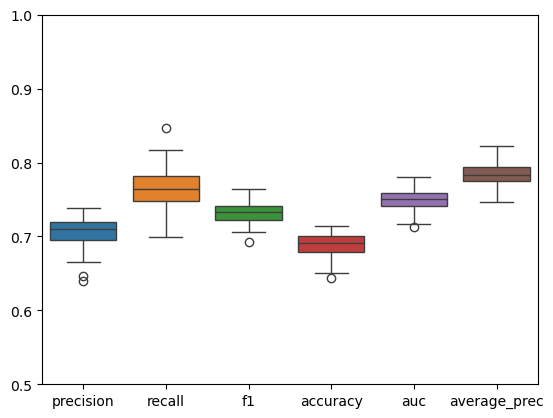

In [36]:
fig, ax = plt.subplots()

df_7 = df.copy()
df_7["vars"] = "fs_7"

sns.boxplot(data=df_7)
ax.set_ylim(0.5, 1)

# Compare:  all features - FS non-strict (7 vars) - FS strict (5 vars)

In [42]:
df_comb = pd.concat([df_15, df_7, df_5], axis=0, ignore_index=True)

Text(0.5, 0, 'ROC-AUC')

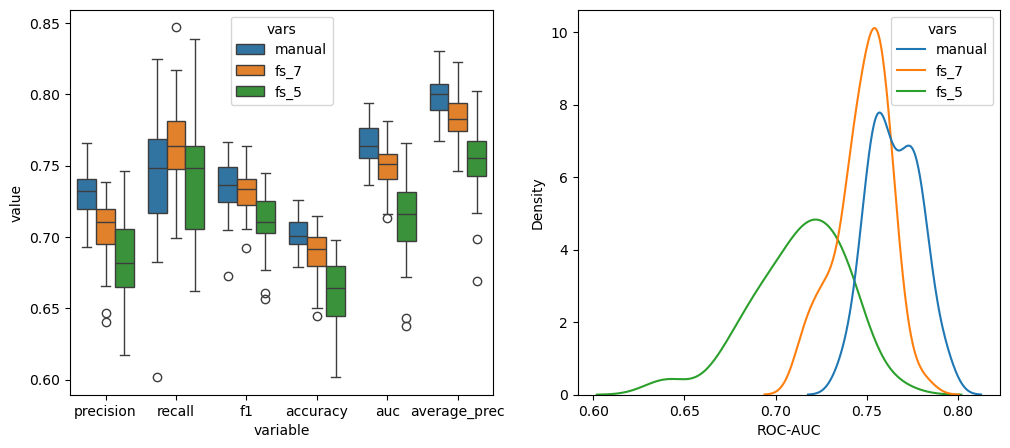

In [45]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

tmp = df_comb.melt(["vars"])
sns.boxplot(data=tmp, x= "variable", y="value", hue="vars", ax=ax1)

tmp2 = df_comb.loc[:,["auc", "vars"]].melt(["vars"])
sns.kdeplot(data=tmp2, x="value", hue="vars", ax=ax2)
ax2.set_xlabel("ROC-AUC")